In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
def profile(skus: list, df: pd.DataFrame, bakery: str):
    df_bakery = df[df['Касса.Торговая точка'] == bakery]
    
    bakery_hour = df_bakery.groupby(['date', 'hour'])['Кол-во'].sum().rename('bakery_total')

    hourly_base = bakery_hour.reset_index()
    hourly_base['week'] = hourly_base['date'].dt.day_of_week

    w_h_profiles = []
    shares_list = [] # Список для сбора колонок share
    skus_sales = []


    for i, sku_name in enumerate(skus, start=1):
        col_name = f"SKU_{i}_share"

        # Считаем продажи SKU
        sku_sales = df_bakery[df_bakery['Номенклатура'] == sku_name].groupby(['date', 'hour'])['Кол-во'].sum()
        skus_sales.append(sku_sales)
        # Считаем долю (Pandas сопоставит индексы date/hour сам)
        share_series = (sku_sales / bakery_hour).rename(col_name).fillna(0)
        print(len(share_series))
        shares_list.append(share_series)
        # Подготовка данных для профиля
        share_df = share_series.reset_index()
        share_df['week'] = share_df['date'].dt.day_of_week
        # Считаем профиль (средняя доля по дню недели и часу)
        # 1. Считаем базовый профиль (средняя доля по дню недели и часу)
        profile_raw = share_df.groupby(['week', 'hour'], as_index=False)[col_name].mean()
        # 2. Считаем среднюю долю для всего дня недели (чтобы сравнить с каждым часом)
        # transform('mean') создаст колонку, где для каждой строки будет среднее её дня недели

        # -----------
        # week_avg = profile_raw.groupby('week')[col_name].transform('mean')
        week_avg = profile_raw.groupby('week')[col_name].transform('median')
        # week_avg = profile_raw.groupby('week')[col_name].transform(lambda x: x.quantile(0.75))
        # -----------       
        # 3. Заменяем значения: если час ниже среднего по дню, берем среднее по дню
        profile_raw[col_name] = profile_raw[col_name].where(profile_raw[col_name] >= week_avg, week_avg)
        # 4. Превращаем обратно в Series с индексом для мерджа, как было раньше
        profile = profile_raw.set_index(['week', 'hour'])[col_name]

        w_h_profiles.append(profile)
        # profile = share_df.groupby(['week', 'hour'])[col_name].mean()
        # w_h_profiles.append(profile)
    hourly = hourly_base.set_index(['date', 'hour']).join(shares_list, how='left').reset_index()
    return w_h_profiles, hourly, shares_list, skus_sales

In [97]:
import pandas as pd

def rolling_mean(skus: list, df_bakery: pd.DataFrame, window=28, col_name='bakery_daily_total'):
    # 1. Фильтруем по нужным SKU и сортируем по времени, чтобы MA считалось корректно
    df_filtered = (
        df_bakery[df_bakery['Номенклатура'].isin(skus)]
        .sort_values(by=['Номенклатура', 'date', 'hour'])
    )
    
    # 2. Группируем по товару, дате и часу и суммируем количество продаж
    # as_index=False оставляет 'Номенклатура', 'date' и 'hour' обычными колонками
    df_aggregated = (
        df_filtered
        .groupby(['Номенклатура', 'date'], as_index=False)[col_name]
        .sum()
    )
    
    # 3. Считаем скользящее среднее по колонке col_name ('Кол-во') строго внутри каждого SKU
    df_aggregated['MA'] = (
        df_aggregated
        .groupby('Номенклатура')[col_name]
        .rolling(window=window, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True) # сбрасываем индекс группировки для корректной записи в df
    )
    
    return df_aggregated

In [29]:
def scaling_by_sku(df: pd.DataFrame, skus: list, col_x: str, col_y: str):
    epsilon = 1e-8

    # 1. Сразу фильтруем по нужным SKU, чтобы не делать лишнюю работу
    df_filtered = df[df['Номенклатура'].isin(skus)].copy()

    # 2. Считаем локальные метрики для каждой группы (SKU)
    # .transform('mean') вернет серию, где для каждой строки будет стоять среднее именно ЕЁ товара
    group = df_filtered.groupby('Номенклатура')
    
    mu_x = group[col_x].transform('mean')
    sigma_x = group[col_x].transform('std')
    
    mu_y = group[col_y].transform('mean')
    sigma_y = group[col_y].transform('std')

    # 3. Проводим Z-масштабирование (Z-score normalization) с учетом локальных метрик
    # Заполняем NaN в std нулями на случай, если у товара всего 1 запись (std будет NaN)
    sigma_x = sigma_x.fillna(0)
    sigma_y = sigma_y.fillna(0)

    new_col_name = f'{col_x}_scaled_like_{col_y}'
    df_filtered[new_col_name] = ((df_filtered[col_x] - mu_x) / (sigma_x + epsilon)) * sigma_y + mu_y

    return df_filtered

In [120]:
def proccess(hourly, w_h_profiles, skus_sales, scaled_rolling_means):
    # Работаем в копии, чтобы не испортить оригинал
    df_res = hourly.copy()
    
    # 1. Присоединяем отмасштабированный тренд (MA) по дате и часу
    # Это ВАЖНО: MA должна быть часовой, чтобы соотноситься с часовым профилем
    if 'MA_x_scaled_like_MA_y' in scaled_rolling_means.columns:
        # Убеждаемся, что мержим по времени
        df_res = df_res.merge(
            scaled_rolling_means[['date', 'hour', 'MA_x_scaled_like_MA_y']], 
            on=['date', 'hour'], 
            how='left'
        )

    for i, profile in enumerate(w_h_profiles, start=1):
        col_name = f"SKU_{i}_share"
        profile_col = f"{col_name}_profile"
        skus_sale_col = f"SKU_{i}_sales"
        restored_col = f"SKU_{i}_restored"
        
        # 2. Присоединяем часовой профиль (по week и hour)
        # profile — это исходная серия с мультииндексом (week, hour)
        df_res = df_res.merge(profile.rename(profile_col), on=['week', 'hour'], how='left')
        
        # 3. Присоединяем факт продаж SKU
        current_sku_sales = skus_sales[i-1].rename(skus_sale_col).reset_index()
        df_res = df_res.merge(current_sku_sales, on=['date', 'hour'], how='left')
        
        # 4. ВОССТАНАВЛИВАЕМ (в часах!)
        # Умножаем часовой MA на часовую долю
        df_res[restored_col] = df_res[profile_col] * df_res['MA_x_scaled_like_MA_y']
        
    df_res = df_res.fillna(0)

    # 5. АГРЕГИРУЕМ В ДНИ только в самом конце
    cols_to_sum = [c for c in df_res.columns if 'sales' in c or 'restored' in c or 'bakery_total' in c]
    # Для тренда (MA) лучше взять среднее, а не сумму, чтобы он не улетал в космос
    daily = df_res.groupby('date').agg({
        **{col: 'sum' for col in cols_to_sum},
        'MA_x_scaled_like_MA_y': 'mean' 
    }).reset_index()
    
    daily['week'] = daily['date'].dt.day_of_week
    
    return df_res, daily

In [3]:
BAKERY = 'Проспект Победы 147 Казань'
SKU_1 = 'Треугольник курица безд'
SKU_2 = 'Вак-бэлиш'
SKU_3 = 'Треугольник говядина безд'
SKU_4 = 'Кыстыбый П'

df = pd.read_csv('C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/raw/sales_hrs_all.csv')
df['Дата продажи'] = pd.to_datetime(df['Дата продажи'], errors="coerce", dayfirst=True)
df['Дата время чека'] = pd.to_datetime(df['Дата время чека'], errors="coerce", dayfirst=True)

df["date"] = df['Дата продажи'].dt.normalize()
df["hour"] = df['Дата время чека'].dt.hour

In [17]:
df_bakery = df[df['Касса.Торговая точка'] == BAKERY]

In [46]:
w_h_profiles, hourly, shares_list, skus_sales = profile([SKU_1, SKU_2, SKU_3, SKU_4], df, BAKERY)

3448
3448
3448
3448


In [52]:
w_h_profiles

[week  hour
 0     6       0.134615
       7       0.081619
       8       0.084067
       9       0.076498
       10      0.079916
                 ...   
 6     17      0.080586
       18      0.078641
       19      0.078641
       20      0.079627
       21      0.078641
 Name: SKU_1_share, Length: 115, dtype: float64,
 week  hour
 0     6       0.024038
       7       0.027337
       8       0.019807
       9       0.028394
       10      0.011767
                 ...   
 6     17      0.010250
       18      0.010250
       19      0.010250
       20      0.011329
       21      0.010250
 Name: SKU_2_share, Length: 115, dtype: float64,
 week  hour
 0     6       0.069231
       7       0.053500
       8       0.039046
       9       0.053078
       10      0.039046
                 ...   
 6     17      0.049876
       18      0.039325
       19      0.039325
       20      0.039325
       21      0.039325
 Name: SKU_3_share, Length: 115, dtype: float64,
 week  hour
 0     6     

In [9]:
df

,Дата продажи,Дата время чека,Вид события по кассе,Касса.Торговая точка,Категория,Номенклатура,Свежесть,Цена,Кол-во,date,hour
0,2026-01-01,2026-01-01 14:21:01,Продажа,Раскольникова 48/1 Наб Челны,Напитки горячие,Капучино 300,NaN,130.0,1.0,2026-01-01,14
1,2026-01-01,2026-01-01 14:21:01,Продажа,Раскольникова 48/1 Наб Челны,Пирожные,Красный Вельвет,Свежий,104.0,1.0,2026-01-01,14
2,2026-01-01,2026-01-01 14:34:10,Продажа,Раскольникова 48/1 Наб Челны,Прочие товары,Тесто дрожжевое,NaN,150.0,0.5,2026-01-01,14
3,2026-01-01,2026-01-01 14:37:17,Продажа,Раскольникова 48/1 Наб Челны,Пирожные,Красный Вельвет,Свежий,104.0,3.0,2026-01-01,14
4,2026-01-01,2026-01-01 14:37:17,Продажа,Раскольникова 48/1 Наб Челны,Кулинария сеть,Манты с говядиной и картофелем вес сеть,NaN,890.0,1.2,2026-01-01,14
...,...,...,...,...,...,...,...,...,...,...,...
29909054,2025-09-30,2025-09-30 23:34:54,Продажа,Энгельса 30 Зеленодольск,Кулинария сеть,Салат Цезарь вес сеть,NaN,849.0,0.2,2025-09-30,23
29909055,2025-09-30,2025-09-30 23:34:54,Продажа,Энгельса 30 Зеленодольск,Прочие товары,Коррекс мал,Свежий,6.0,1.0,2025-09-30,23
29909056,2025-09-30,2025-09-30 23:34:54,Продажа,Энгельса 30 Зеленодольск,Выпечка сытная,ЖарЧизбургер,Свежий,140.0,2.0,2025-09-30,23
29909057,2025-09-30,2025-09-30 23:36:19,Продажа,Шамиля Усманова 47 Наб Челны,Напитки горячие,Капучино 300,Свежий,130.0,1.0,2025-09-30,23


In [22]:
bakery_hour = df_bakery.groupby(['date', 'hour'])['Кол-во'].sum().reset_index(name='bakery_total')

In [23]:
bakery_hour

,date,hour,bakery_total
0,2025-08-01,6,0.0
1,2025-08-01,7,72.9
2,2025-08-01,8,59.6
3,2025-08-01,9,38.1
4,2025-08-01,10,41.5
...,...,...,...
3443,2026-04-02,17,82.7
3444,2026-04-02,18,75.9
3445,2026-04-02,19,22.6
3446,2026-04-02,20,30.0


In [90]:
bakery_day = bakery_hour.groupby('date')['bakery_total'].sum().reset_index(name='bakery_daily_total')

In [80]:
bakery_hour['MA'] = bakery_hour['bakery_total'].rolling(window=28, min_periods=1).mean()

In [91]:
bakery_day['MA'] = bakery_day['bakery_daily_total'].rolling(window=28, min_periods=1).mean()

In [92]:
bakery_day.tail(30)

,date,bakery_daily_total,MA
206,2026-02-24,705.8,640.692857
207,2026-02-25,725.7,639.739286
208,2026-02-26,636.8,637.900000
209,2026-02-27,681.5,638.642857
210,2026-02-28,642.4,636.771429
211,2026-03-01,604.5,641.775000
212,2026-03-10,595.4,642.514286
213,2026-03-11,628.0,646.064286
214,2026-03-12,735.4,650.539286
215,2026-03-13,910.6,656.989286


In [100]:
rolling_df = rolling_mean([SKU_1, SKU_2, SKU_3, SKU_4], df[df['Касса.Торговая точка'] == BAKERY], window=28, col_name='Кол-во')

In [102]:
rolling_df

,Номенклатура,date,Кол-во,MA
0,Вак-бэлиш,2025-08-01,12.0,12.000000
1,Вак-бэлиш,2025-08-03,1.0,6.500000
2,Вак-бэлиш,2025-08-04,3.0,5.333333
3,Вак-бэлиш,2025-08-05,6.0,5.500000
4,Вак-бэлиш,2025-08-06,8.0,6.000000
...,...,...,...,...
929,Треугольник курица безд,2026-03-29,36.0,48.535714
930,Треугольник курица безд,2026-03-30,39.0,48.500000
931,Треугольник курица безд,2026-03-31,64.0,50.178571
932,Треугольник курица безд,2026-04-01,52.0,50.142857


In [104]:
rolling_df = rolling_df.merge(bakery_day, on=['date'], how='left')

In [38]:
bakery_hour

,date,hour,bakery_total,MA
0,2025-08-01,6,0.0,0.000000
1,2025-08-01,7,72.9,36.450000
2,2025-08-01,8,59.6,44.166667
3,2025-08-01,9,38.1,42.650000
4,2025-08-01,10,41.5,42.420000
...,...,...,...,...
3443,2026-04-02,17,82.7,60.407143
3444,2026-04-02,18,75.9,62.235714
3445,2026-04-02,19,22.6,62.432143
3446,2026-04-02,20,30.0,61.039286


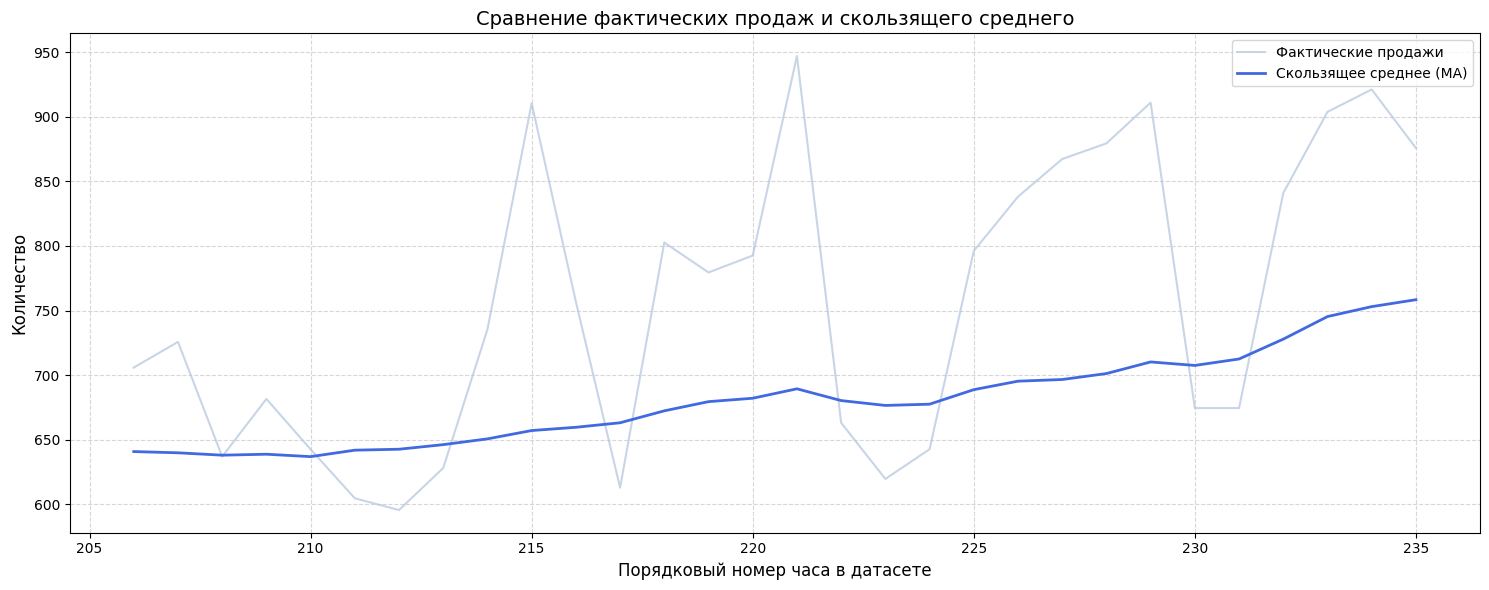

In [94]:
import matplotlib.pyplot as plt

# Устанавливаем размер графика
plt.figure(figsize=(15, 6))

# 1. Рисуем фактические продажи (сделаем их чуть бледнее, чтобы MA выделялось)
plt.plot(bakery_day.tail(30).index, bakery_day.tail(30)['bakery_daily_total'], label='Фактические продажи', color='lightsteelblue', alpha=0.7)

# 2. Рисуем скользящее среднее (более яркой и толстой линией)
plt.plot(bakery_day.tail(30).index, bakery_day.tail(30)['MA'], label='Скользящее среднее (MA)', color='royalblue', linewidth=2)

# Настройка осей и заголовков
plt.title('Сравнение фактических продаж и скользящего среднего', fontsize=14)
plt.xlabel('Порядковый номер часа в датасете', fontsize=12)
plt.ylabel('Количество', fontsize=12)

# Добавляем сетку и легенду
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [105]:
rolling_df

,Номенклатура,date,Кол-во,MA_x,bakery_daily_total,MA_y
0,Вак-бэлиш,2025-08-01,12.0,12.000000,639.6,639.600000
1,Вак-бэлиш,2025-08-03,1.0,6.500000,379.5,493.933333
2,Вак-бэлиш,2025-08-04,3.0,5.333333,545.5,506.825000
3,Вак-бэлиш,2025-08-05,6.0,5.500000,538.1,513.080000
4,Вак-бэлиш,2025-08-06,8.0,6.000000,632.6,533.000000
...,...,...,...,...,...,...
929,Треугольник курица безд,2026-03-29,36.0,48.535714,674.4,712.442857
930,Треугольник курица безд,2026-03-30,39.0,48.500000,841.0,727.807143
931,Треугольник курица безд,2026-03-31,64.0,50.178571,903.9,745.310714
932,Треугольник курица безд,2026-04-01,52.0,50.142857,921.3,753.007143


In [106]:
scaling_by_sku_df = scaling_by_sku(rolling_df, [SKU_1, SKU_2, SKU_3, SKU_4], col_x='MA_x', col_y='MA_y')

In [107]:
scaling_by_sku_df

,Номенклатура,date,Кол-во,MA_x,bakery_daily_total,MA_y,MA_x_scaled_like_MA_y
0,Вак-бэлиш,2025-08-01,12.0,12.000000,639.6,639.600000,692.575891
1,Вак-бэлиш,2025-08-03,1.0,6.500000,379.5,493.933333,526.514125
2,Вак-бэлиш,2025-08-04,3.0,5.333333,545.5,506.825000,491.288902
3,Вак-бэлиш,2025-08-05,6.0,5.500000,538.1,513.080000,496.321077
4,Вак-бэлиш,2025-08-06,8.0,6.000000,632.6,533.000000,511.417601
...,...,...,...,...,...,...,...
929,Треугольник курица безд,2026-03-29,36.0,48.535714,674.4,712.442857,627.431854
930,Треугольник курица безд,2026-03-30,39.0,48.500000,841.0,727.807143,627.020310
931,Треугольник курица безд,2026-03-31,64.0,50.178571,903.9,745.310714,646.362861
932,Треугольник курица безд,2026-04-01,52.0,50.142857,921.3,753.007143,645.951317


In [116]:
hourly

,date,hour,bakery_total,week,SKU_1_share,SKU_2_share,SKU_3_share,SKU_4_share
0,2025-08-01,6,0.0,4,0.000000,0.0,0.000000,0.000000
1,2025-08-01,7,72.9,4,0.082305,0.0,0.164609,0.013717
2,2025-08-01,8,59.6,4,0.100671,0.0,0.000000,0.016779
3,2025-08-01,9,38.1,4,0.104987,0.0,0.000000,0.000000
4,2025-08-01,10,41.5,4,0.000000,0.0,0.048193,0.024096
...,...,...,...,...,...,...,...,...
3443,2026-04-02,17,82.7,3,0.084643,0.0,0.000000,0.048368
3444,2026-04-02,18,75.9,3,0.052701,0.0,0.013175,0.092227
3445,2026-04-02,19,22.6,3,0.088496,0.0,0.088496,0.000000
3446,2026-04-02,20,30.0,3,0.133333,0.0,0.200000,0.000000


In [121]:
processed_daily = proccess(hourly, w_h_profiles, skus_sales, scaling_by_sku_df)

KeyError: "['hour'] not in index"

In [119]:
processed_daily

,date,week,bakery_total,MA_x_scaled_like_MA_y,SKU_1_share_daily_profile,SKU_1_sales,SKU_1_restored,SKU_2_share_daily_profile,SKU_2_sales,SKU_2_restored,SKU_3_share_daily_profile,SKU_3_sales,SKU_3_restored,SKU_4_share_daily_profile,SKU_4_sales,SKU_4_restored
0,2025-08-01,4,639.6,692.575891,1.530799,41.0,1060.194336,0.429517,12.0,297.472852,0.831851,29.0,576.119913,0.757651,16.0,524.731127
1,2025-08-02,5,462.7,517.871679,1.173930,41.0,607.944922,0.316142,0.0,163.720745,0.806879,31.0,417.859692,0.599385,18.0,310.404630
2,2025-08-03,6,379.5,526.514125,1.483893,40.0,781.290520,0.427326,1.0,224.993252,0.870872,21.0,458.526316,0.637940,16.0,335.884531
3,2025-08-04,0,545.5,491.288902,1.392429,41.0,684.084950,0.264901,3.0,130.142967,0.760599,39.0,373.674062,0.840687,26.0,413.020129
4,2025-08-05,1,538.1,496.321077,1.292468,40.0,641.479179,0.317228,6.0,157.447186,0.788370,12.0,391.284850,0.904460,18.0,448.902667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231,2026-03-29,6,674.4,650.521288,1.483893,36.0,965.303856,0.427326,3.0,277.984755,0.870872,22.0,566.520659,0.637940,43.0,414.993686
232,2026-03-30,0,841.0,661.304520,1.392429,39.0,920.819638,0.264901,13.0,175.180290,0.760599,23.0,502.987845,0.840687,45.0,555.950027
233,2026-03-31,1,903.9,676.401044,1.292468,64.0,874.226799,0.317228,18.0,214.573683,0.788370,29.0,533.254567,0.904460,42.0,611.777832
234,2026-04-01,2,921.3,687.184276,1.444523,52.0,992.653636,0.316369,17.0,217.403571,0.805993,50.0,553.865925,0.823237,55.0,565.715594


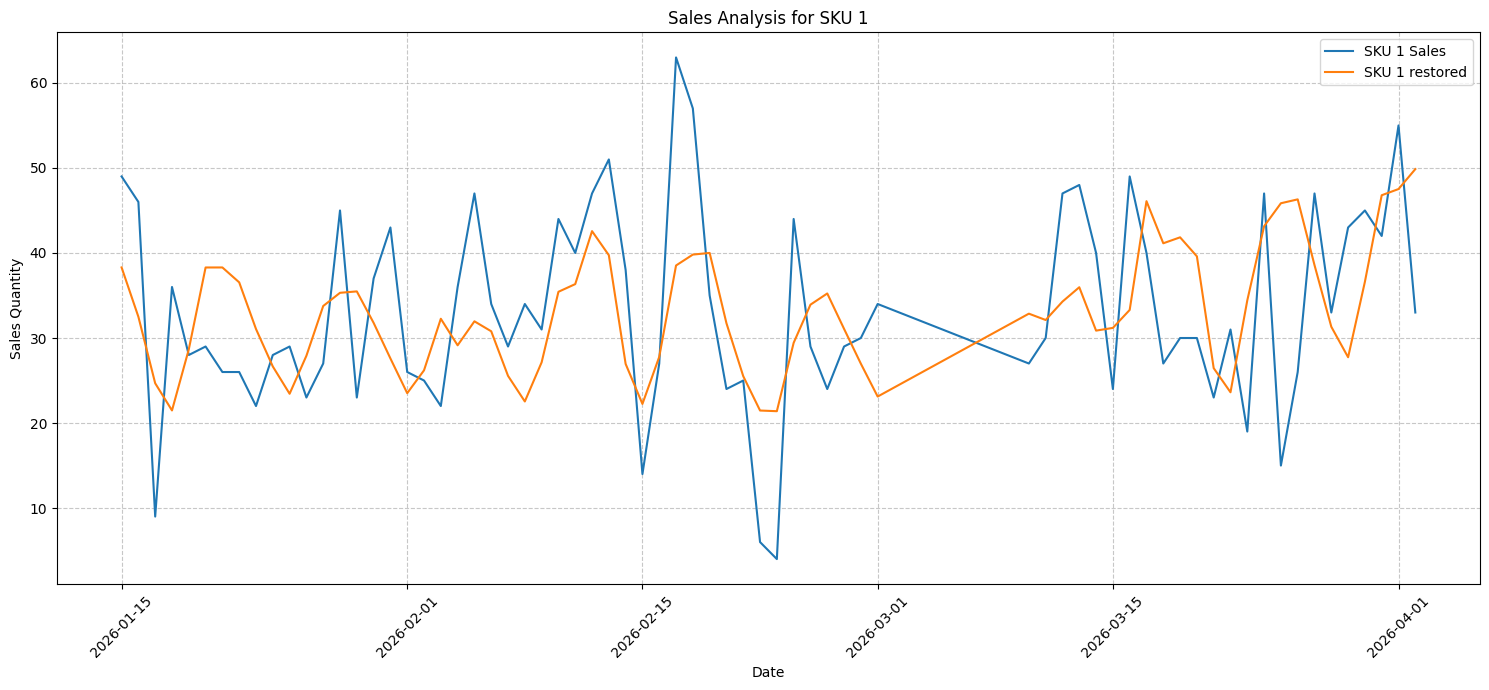

In [89]:
lasts = processed_daily.tail(70)
date = lasts['date']
import matplotlib.pyplot as plt

# 1. Увеличиваем размер (ширина=15, высота=7 дюймов)
plt.figure(figsize=(15, 7))

# 2. Строим график
plt.plot(date, lasts['SKU_4_sales'], label='SKU 1 Sales')
plt.plot(date, lasts['SKU_4_restored'], label='SKU 1 restored')


# Добавляем подписи
plt.xlabel('Date')
plt.ylabel('Sales Quantity')
plt.title('Sales Analysis for SKU 1')

# Добавляем сетку, чтобы было легче анализировать пики
plt.grid(True, linestyle='--', alpha=0.7)

# Если даты на оси X налезают друг на друга, можно их наклонить:
plt.xticks(rotation=45)

# Добавляем легенду
plt.legend()

# Показываем результат
plt.tight_layout() # Автоматически подгоняет отступы, чтобы подписи не обрезались
plt.show()

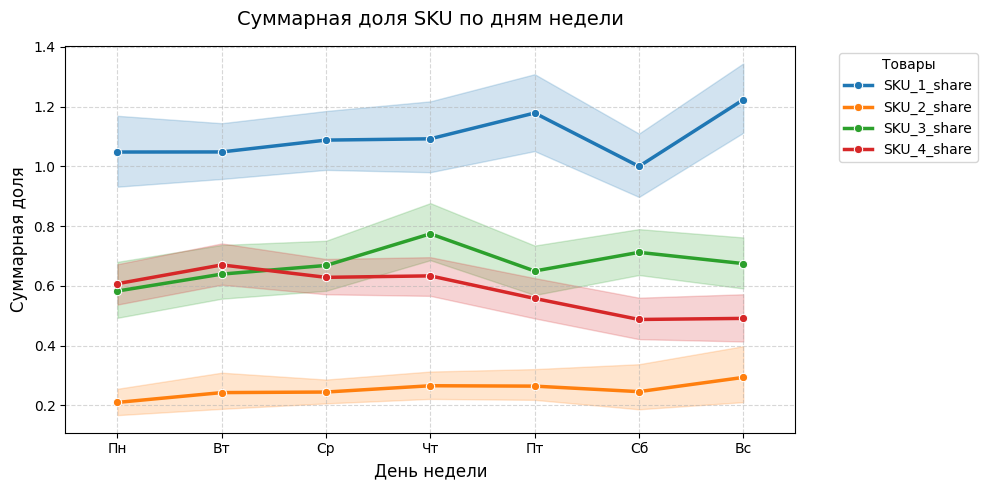

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Объединяем
df_shares = pd.concat(shares_list, axis=1)

# 2. Группируем по первому уровню индекса
df_days = df_shares.groupby(level=0).sum()
df_days.index.name = 'week'

# 3. Переводим в длинный формат
df_melted = df_days.reset_index().melt(
    id_vars='week', 
    var_name='SKU', 
    value_name='Total_Share'
)

# --- КРИТИЧЕСКИЙ ШАГ: Исправляем ось X ---
# Превращаем неделю в обычное целое число (0, 1, 2...), 
# даже если там сейчас странные даты или таймстампы
df_melted['week'] = pd.to_numeric(df_melted['week'], errors='coerce')
# Если вдруг там были даты, вытаскиваем день недели (0-6)
if df_melted['week'].max() > 1000: # признак таймстампа
    df_melted['week'] = pd.to_datetime(df_melted['week']).dt.weekday

# Убираем возможные пустые значения
df_melted = df_melted.dropna(subset=['week'])
# -----------------------------------------

plt.figure(figsize=(10, 5))

# Строим график, явно указав, что week — это категории
sns.lineplot(
    data=df_melted,
    x='week',
    y='Total_Share',
    hue='SKU',
    marker='o',
    linewidth=2.5
)

# Принудительно ставим лимиты оси X от 0 до 6
plt.xlim(-0.5, 6.5)

# Названия дней
days_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
plt.xticks(ticks=range(7), labels=days_labels)

plt.title('Суммарная доля SKU по дням недели', fontsize=14, pad=15)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Суммарная доля', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Товары', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()